In [1]:
'''
Loads the MELCHIORS catalogue.
Converts RA/Dec into astropy.coordinates.SkyCoord.
Filters to Dec > -50°.
Examines every target over January–September 2027.
Calculates altitude and airmass from La Palma.
Requires airmass ≤ 1.2.
Requires the star to be above the horizon and the Sun sufficiently below the horizon.
Reports the best observing time for every candidate.
Calculates Moon separation, but does not use it as a filter yet.
Saves the result as a CSV.
'''


'\nLoads the MELCHIORS catalogue.\nConverts RA/Dec into astropy.coordinates.SkyCoord.\nFilters to Dec > -50°.\nExamines every target over January–September 2027.\nCalculates altitude and airmass from La Palma.\nRequires airmass ≤ 1.2.\nRequires the star to be above the horizon and the Sun sufficiently below the horizon.\nReports the best observing time for every candidate.\nCalculates Moon separation, but does not use it as a filter yet.\nSaves the result as a CSV.\n'

In [2]:
from extracting import *

YEAR = 2027

MIN_DECLINATION = -30.0
MAX_AIRMASS = 1.5
MIN_ALTITUDE = 30.0
MAX_SUN_ALTITUDE = -18.0
TIME_STEP_MINUTES = 15
MIN_CONTINUOUS_HOURS = 6.0
MIN_MOON_SEPARATION_DEG = 60.0


## 1. Load catalogue

In [3]:
# Load and filter catalogue
df = load_catalogue(CATALOGUE_FILE)
df = spectral_type_filter(df)
df = declination_filter(df)
df

Catalogue columns: ['obsID', 'Vmag', 'B-V', 'SpType', 'ra', 'dec', 'airmass', 'exptime', 'SNR-V', 'date-avg', 'FileName']
Total rows: 3,256
Unique stars: 2,096
OBA-type stars: 880
After dec > -30.0°: 879


,obsID,Vmag,B-V,SpType,ra,dec,airmass,exptime,SNR-V,date-avg,FileName
0,307233,4.52,0.05,A2V,00:18:19.70,+36:47:06.79,1.261,81.0,209.3,2010-09-28T03:59:52,me307233.fit
2,307238,5.57,0.40,A8II,00:01:37.00,+61:13:22.12,1.553,500.0,317.2,2010-09-28T04:43:18,me307238.fit
4,307340,6.77,0.19,A5/7III,02:29:55.40,-22:40:59.52,1.820,1800.0,279.0,2010-09-29T05:04:50,me307340.fit
11,307473,6.77,0.19,A5/7III,02:29:55.30,-22:40:59.52,1.603,700.0,160.0,2010-10-01T03:09:56,me307473.fit
13,307478,5.88,-0.02,A0IV,00:18:38.30,+31:31:01.99,1.443,300.0,191.5,2010-10-01T04:29:10,me307478.fit
...,...,...,...,...,...,...,...,...,...,...,...
3250,957486,4.63,-0.11,B7V,07:35:22.89,-28:22:09.55,1.937,91.0,199.0,2020-02-11T00:28:08,me957486.fit
3251,957613,7.46,-0.18,B1III,07:19:09.91,-25:33:57.20,1.869,900.0,148.7,2020-02-12T00:34:22,me957613.fit
3252,957614,6.26,-0.15,B2III,06:59:39.25,-21:36:10.37,1.875,350.0,158.6,2020-02-12T00:47:05,me957614.fit
3253,957615,6.61,-0.01,A0IV,07:26:40.68,-23:42:45.40,1.865,529.0,157.5,2020-02-12T00:56:42,me957615.fit


In [4]:
# Calculate visibility with continuity constraint
df, nights, n_nights, n_times, visibility_per_night, continuous_hours_grid = calculate_visibility(df)


Calculating visibility for 879 stars over 273 nights...
  Processing night 1/273: 2027-01-01
  Processing night 31/273: 2027-01-31
  Processing night 61/273: 2027-03-02
  Processing night 91/273: 2027-04-01
  Processing night 121/273: 2027-05-01
  Processing night 151/273: 2027-05-31
  Processing night 181/273: 2027-06-30
  Processing night 211/273: 2027-07-30
  Processing night 241/273: 2027-08-29


  Processing night 271/273: 2027-09-28

Visibility calculation complete.


In [5]:
heatmap = compute_heatmap(df, n_nights, n_times, visibility_per_night, continuous_hours_grid)



Building heatmap...

Heatmap built.


In [6]:
# # Filter: require >= MIN_CONTINUOUS_HOURS continuous
# print(f"\nFiltering for ≥{MIN_CONTINUOUS_HOURS} continuous hours...")
# df_good = df[df["best_continuous_hours"] >= MIN_CONTINUOUS_HOURS].copy()
# print(f"Stars with ≥{MIN_CONTINUOUS_HOURS}h continuous: {len(df_good)}")
# df_good

In [7]:
# # Sort by best airmass (lowest = best)
# df_good = df_good.sort_values("best_airmass", ascending=True)

# # Print summary
# columns = []
# for col in [
#     "obsID", "Vmag", "SpType", "ra", "dec",
#     "best_altitude_deg", "best_airmass",
#     "best_continuous_hours", "best_observing_time_utc",  #"best_moon_separation_deg",
#      "best_month",
# ]:   
#     if col in df_good.columns:
#         columns.append(col)

# print(f"\nTop candidates ({min(30, len(df_good))} shown):")
# print(df_good[columns].head(30).to_string(index=False))

In [8]:
# plot_month_histogram(df_good)



Heatmap saved: plots/telluric_visibility_heatmap_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


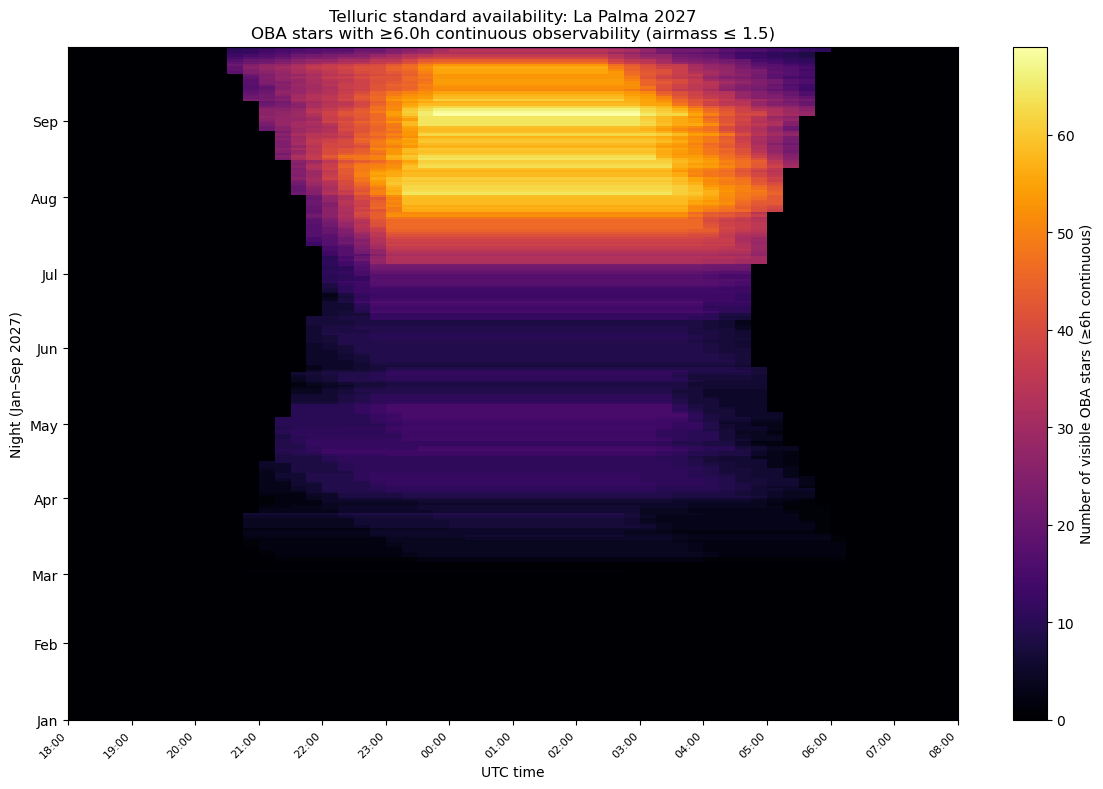

In [9]:
plot_visibility_heatmap(heatmap, nights)


Saved: plots/stars_per_night_Jan_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


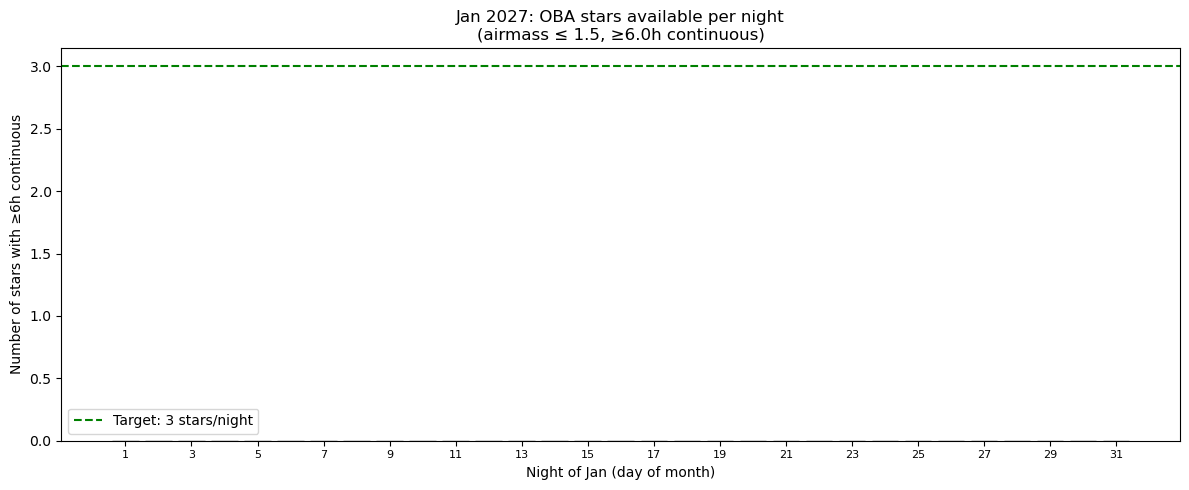

Saved: plots/stars_per_night_Feb_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


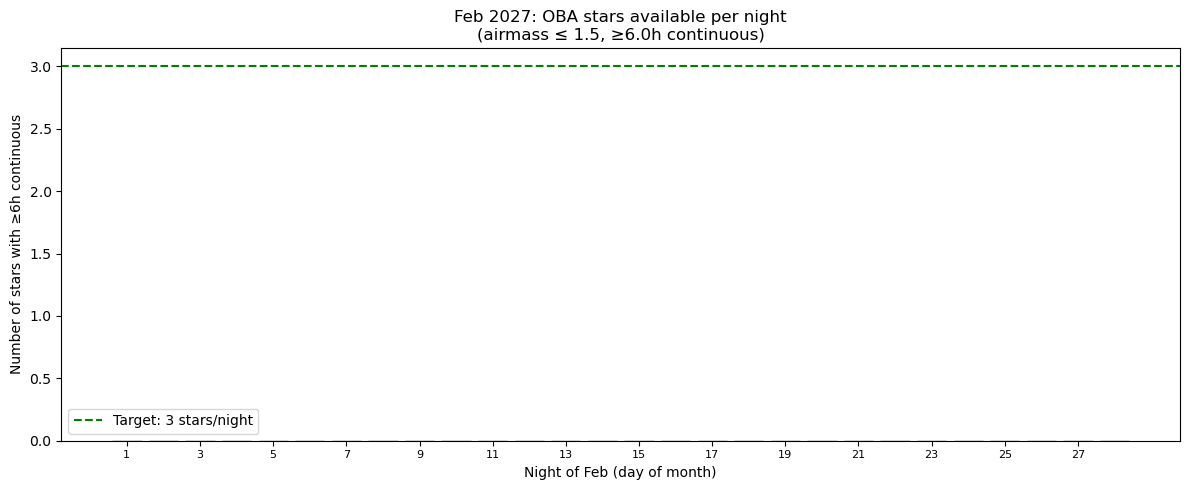

Saved: plots/stars_per_night_Mar_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


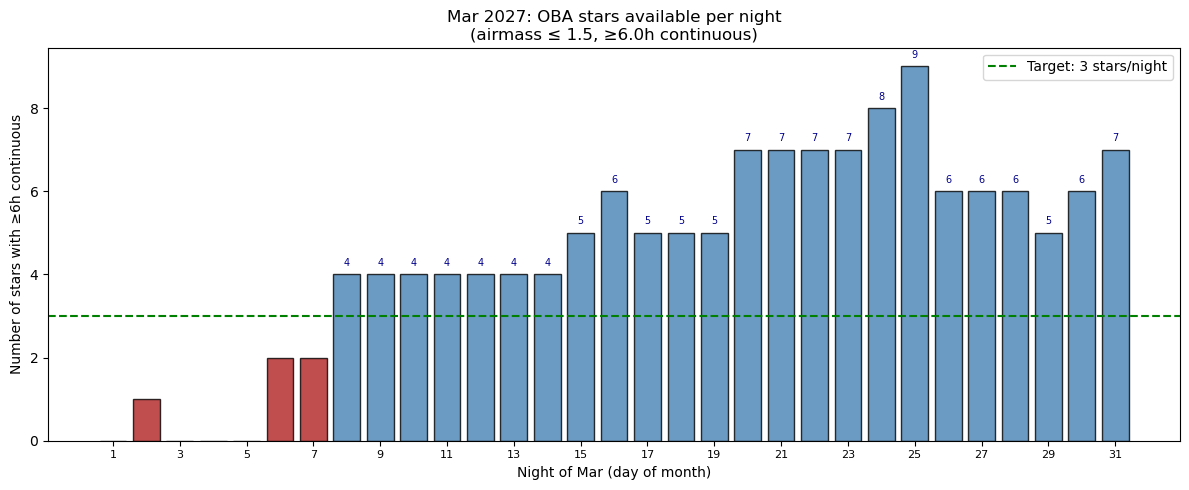

Saved: plots/stars_per_night_Apr_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


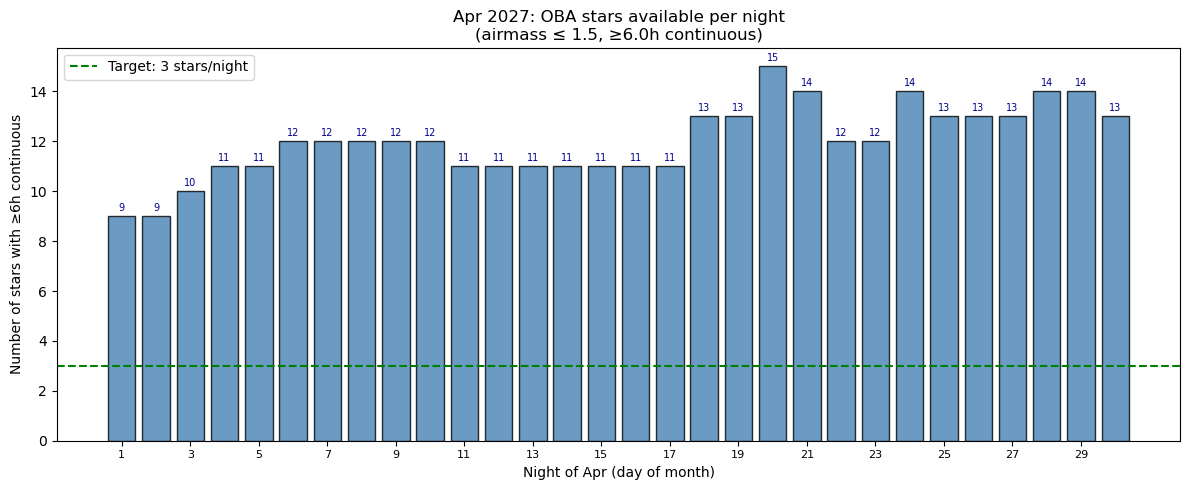

Saved: plots/stars_per_night_May_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


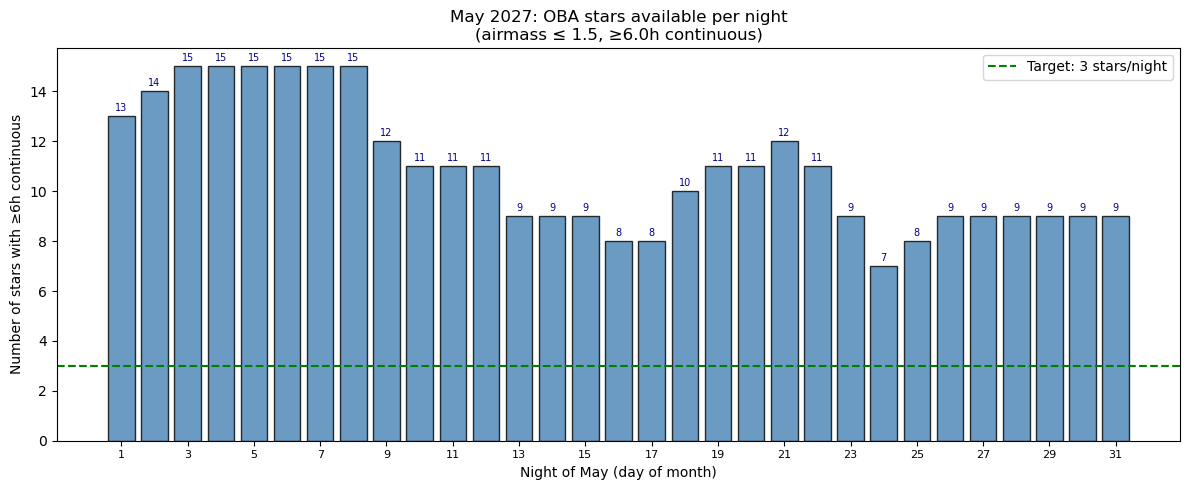

Saved: plots/stars_per_night_Jun_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


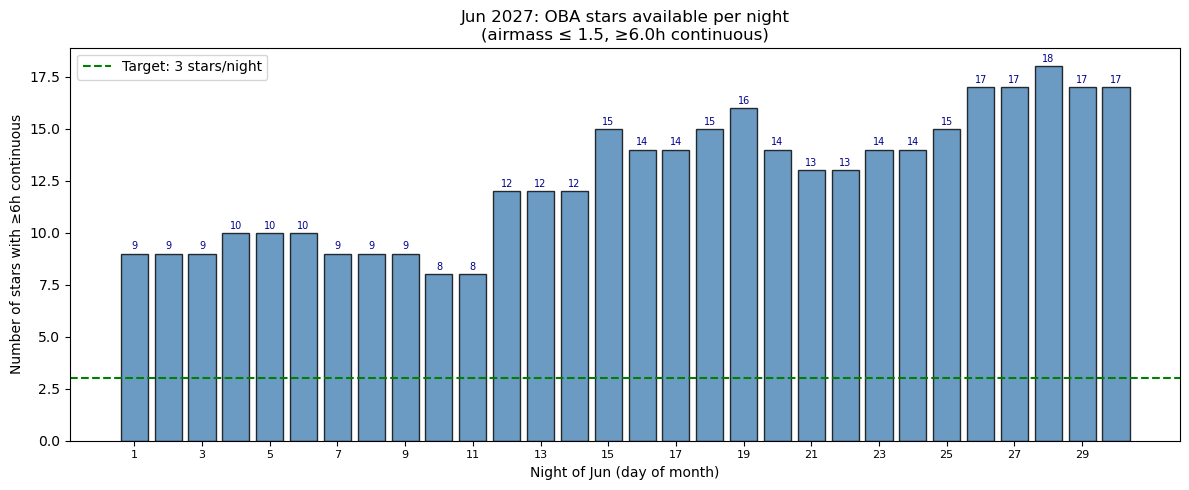

Saved: plots/stars_per_night_Jul_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


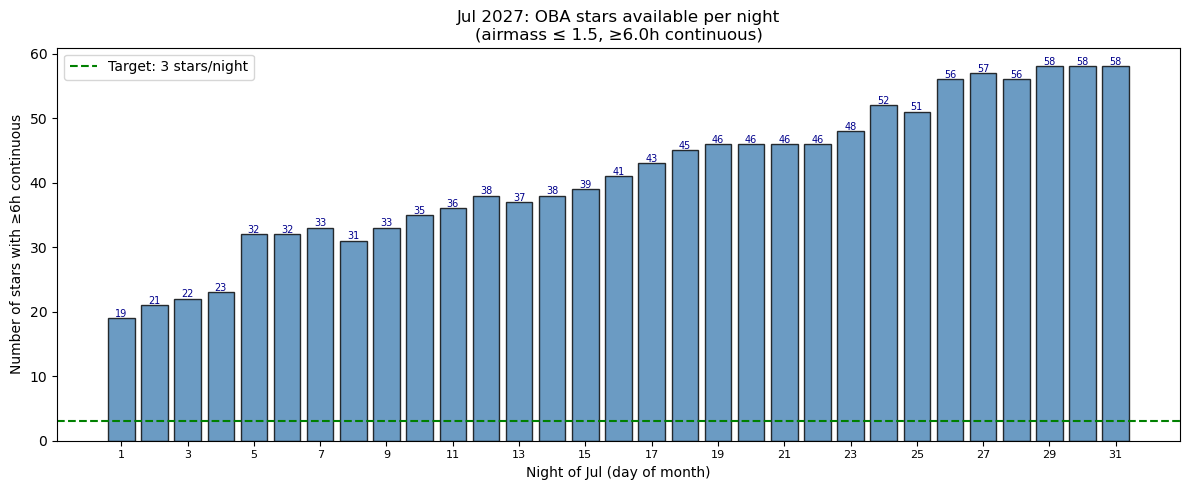

Saved: plots/stars_per_night_Aug_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


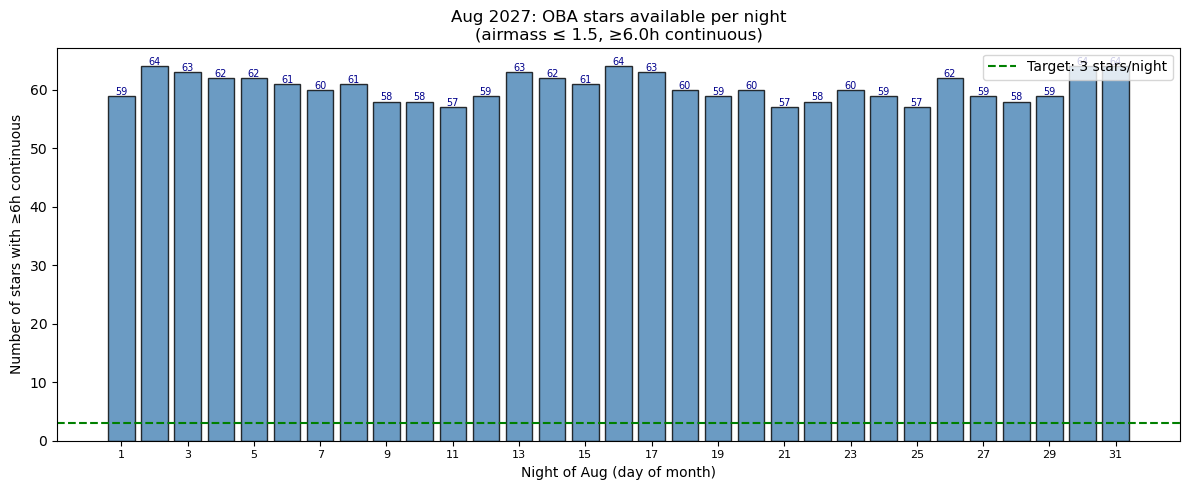

Saved: plots/stars_per_night_Sep_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


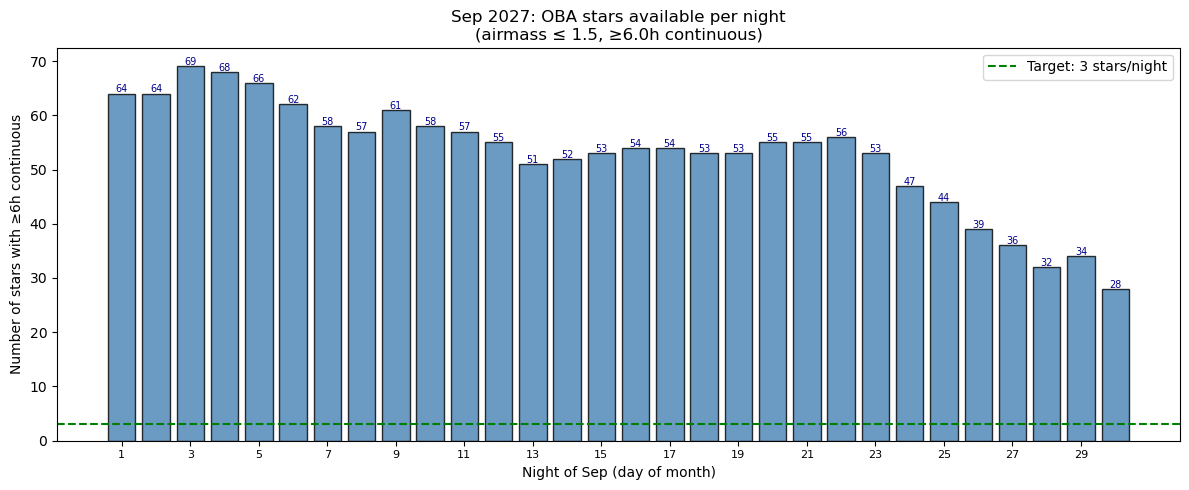


Nights with ≥3 stars available (good for 2-3 day observing runs):
  2027-03-08  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-09  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-10  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-11  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-12  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-13  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-14  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-15  (Mar): 5 stars — 328668, 328669, 340647, 347422, 349382
  2027-03-16  (Mar): 6 stars — 328668, 328669, 340647, 347422, 349382, 350658
  2027-03-17  (Mar): 5 stars — 328668, 328669, 347422, 349382, 350658
  2027-03-18  (Mar): 5 stars — 328668, 328669, 347422, 349382, 350658
  2027-03-19  (Mar): 5 stars — 328668, 328669, 340647, 347422, 349382
  2027-03-20  (Mar): 7 stars — 328668, 328669, 340647, 347422, 349382, 391621, 391622
  2027-03-21  (Mar): 7 stars — 328668, 328669, 340647, 

In [10]:
## per month

stars_by_night = plot_stars_per_night_by_month(df, nights, continuous_hours_grid)

In [11]:
stars_by_night["2027-03-15"]   # -> [349382, ...]  (>=6h continuous that night)


[328668, 328669, 340647, 347422, 349382]

In [12]:
date = "2027-05-03"
table = tabulate_by_obsids(df, stars_by_night[date], save_csv=f"etc_input_{date}.csv")
table                             
# or directly with a hand-picked list:
# tabulate_by_obsids(df, [349382, 100200, 123456], save_csv="etc_input.csv")    


Saved table to: etc_input_2027-05-03.csv


,obsID,Vmag,SpType,ra,dec,airmass,exptime
0,327246,1.86,B3V,13:47:32.40,+49:18:47.81,1.067082,20.0
1,327341,2.20,A1V,13:23:55.20,+54:55:25.00,1.112866,31.5
2,327657,4.71,B9III,16:02:47.90,+46:02:12.08,1.047094,250.0
3,327764,4.20,B9V,16:34:06.20,+42:26:13.31,1.029033,146.0
4,336199,3.87,B5IV,16:19:44.40,+46:18:48.10,1.048589,300.0
5,336615,2.22,A1.5Vas,13:23:55.50,+54:55:31.30,1.112883,687.3
6,340251,4.01,A5V+M3-4V,13:25:13.50,+54:59:16.62,1.113428,70.0
7,340253,4.75,A7V,14:16:09.90,+51:22:01.99,1.082310,130.0
8,340647,3.68,A0III,14:04:23.30,+64:22:33.10,1.228151,60.0
9,340867,4.51,A7IV,14:13:29.00,+51:47:23.89,1.085704,100.0


 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_327246_2027-05-03.pdf


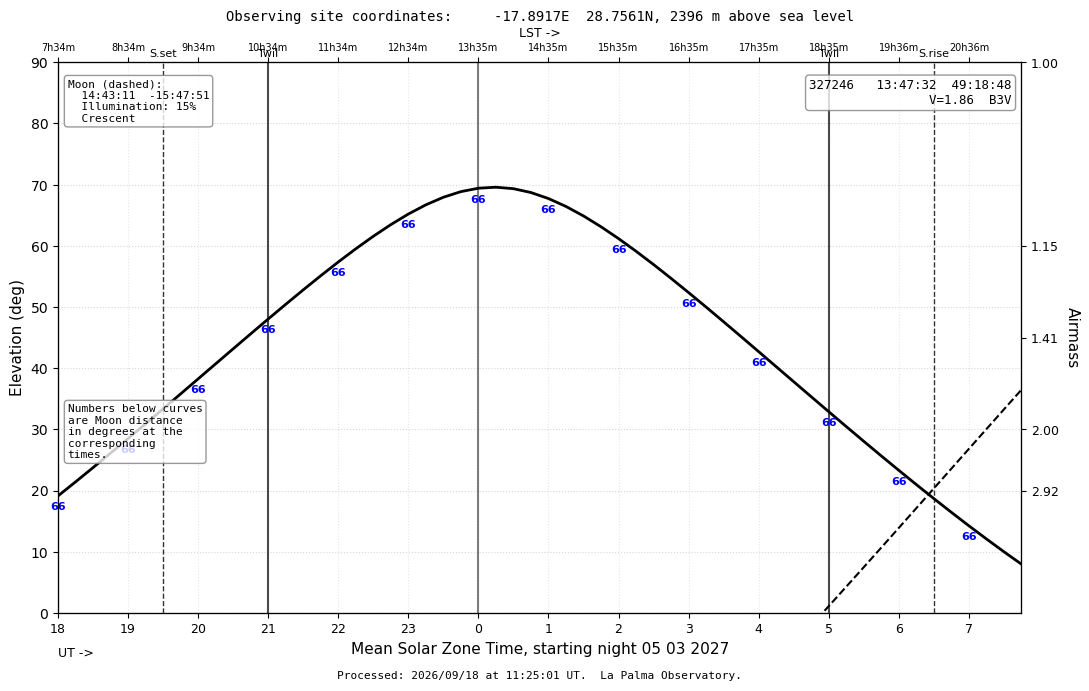

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_327341_2027-05-03.pdf


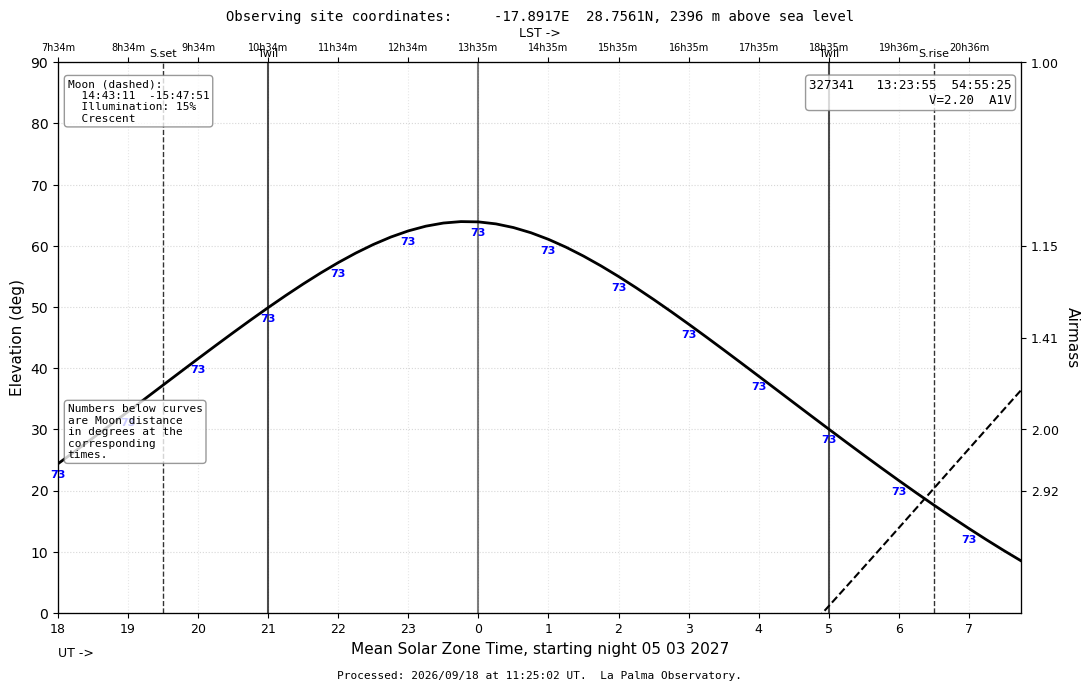

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_327657_2027-05-03.pdf


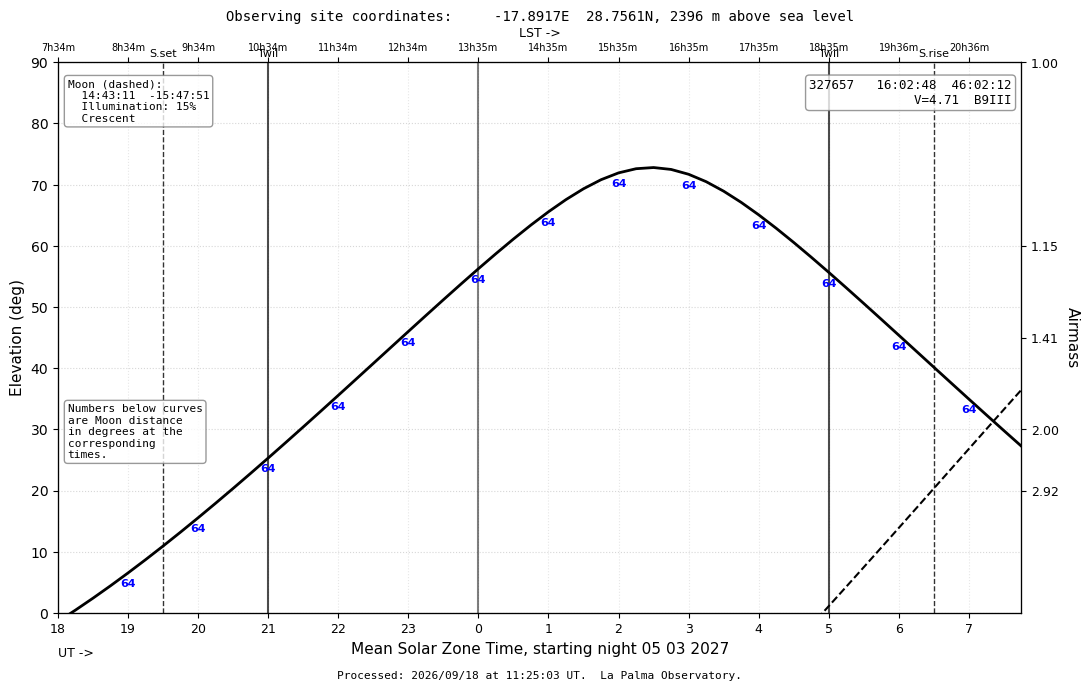

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_327764_2027-05-03.pdf


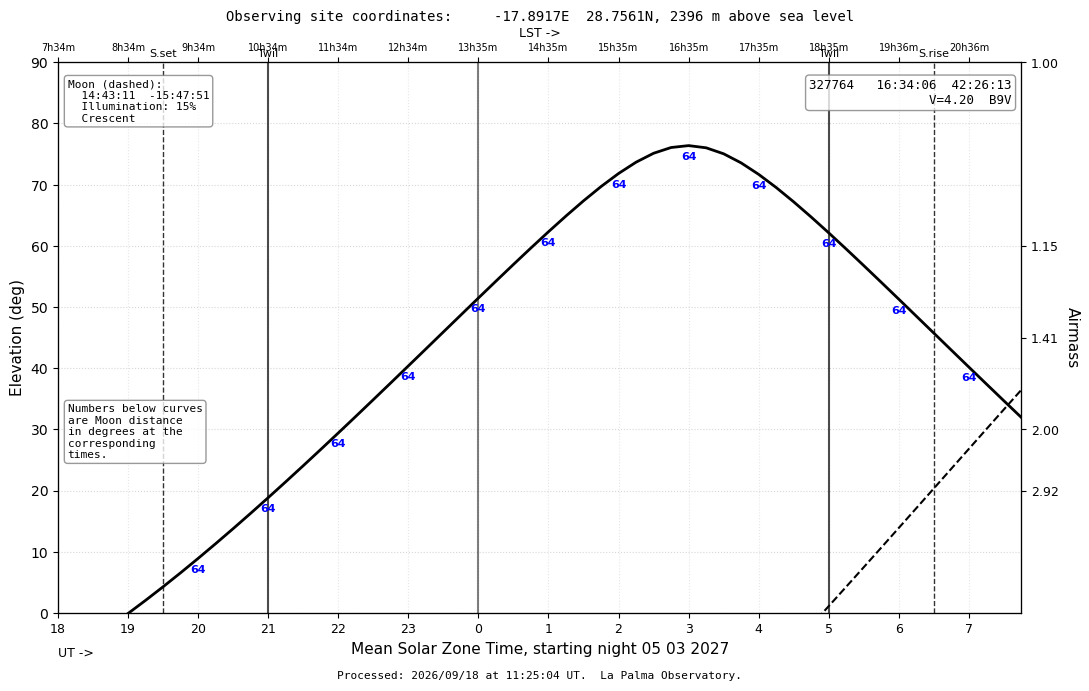

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_336199_2027-05-03.pdf


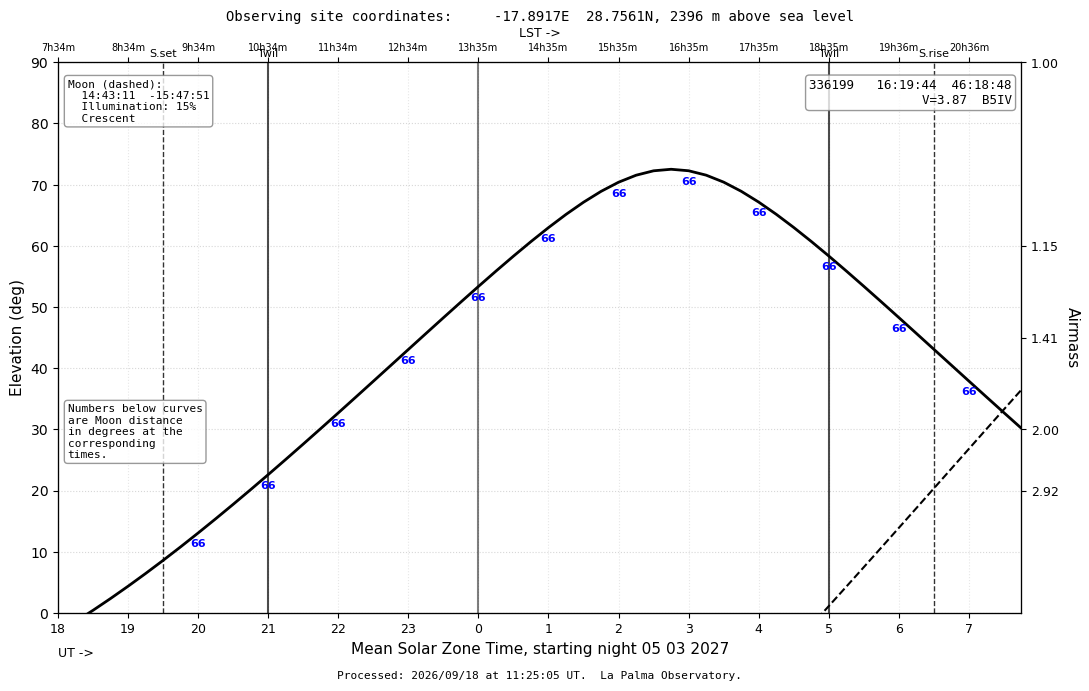

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_336615_2027-05-03.pdf


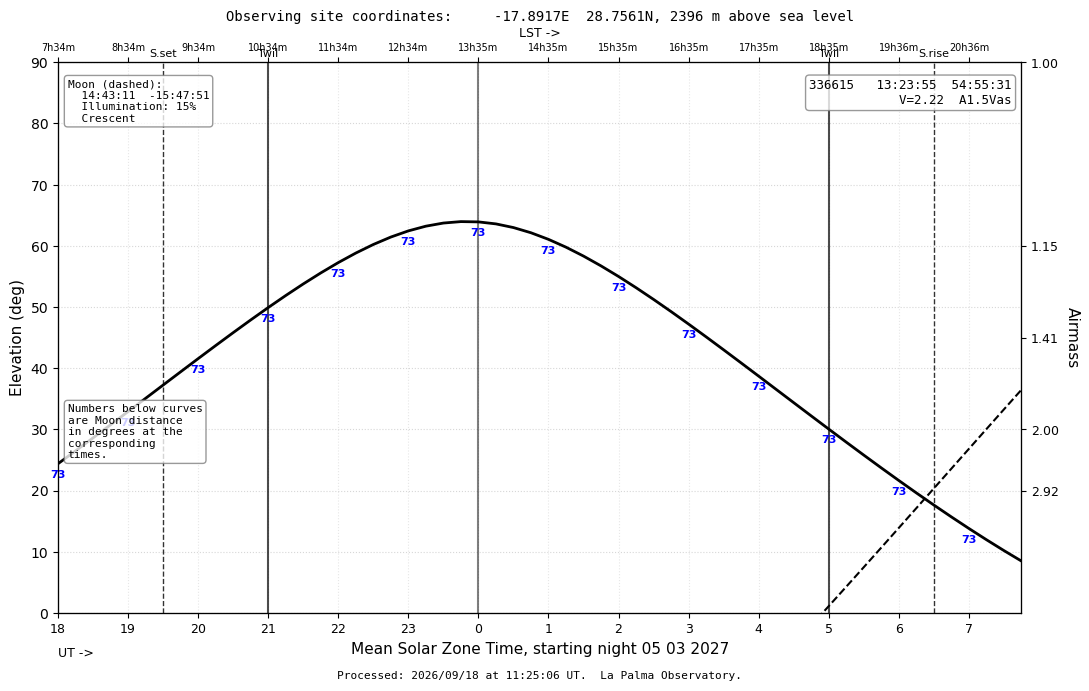

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_340251_2027-05-03.pdf


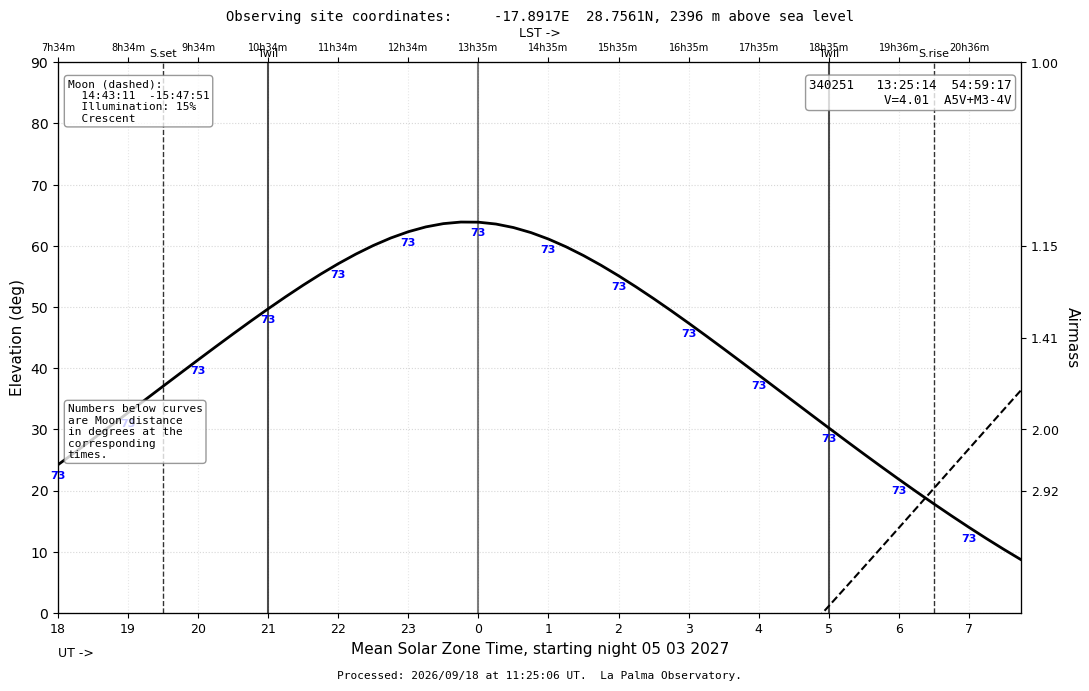

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_340253_2027-05-03.pdf


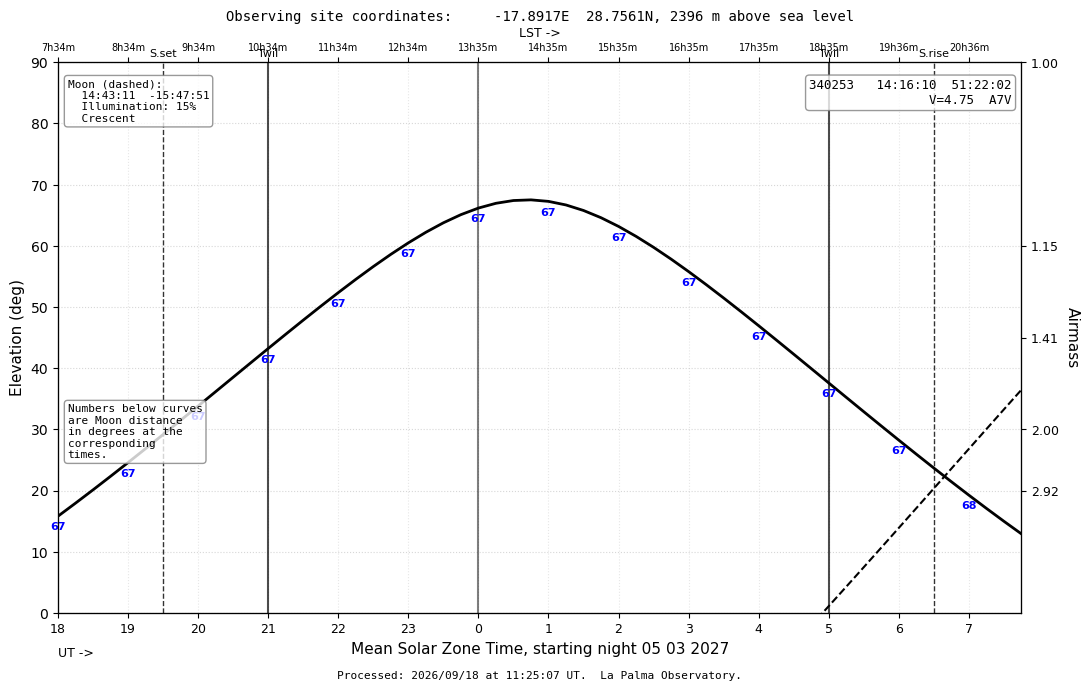

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_340647_2027-05-03.pdf


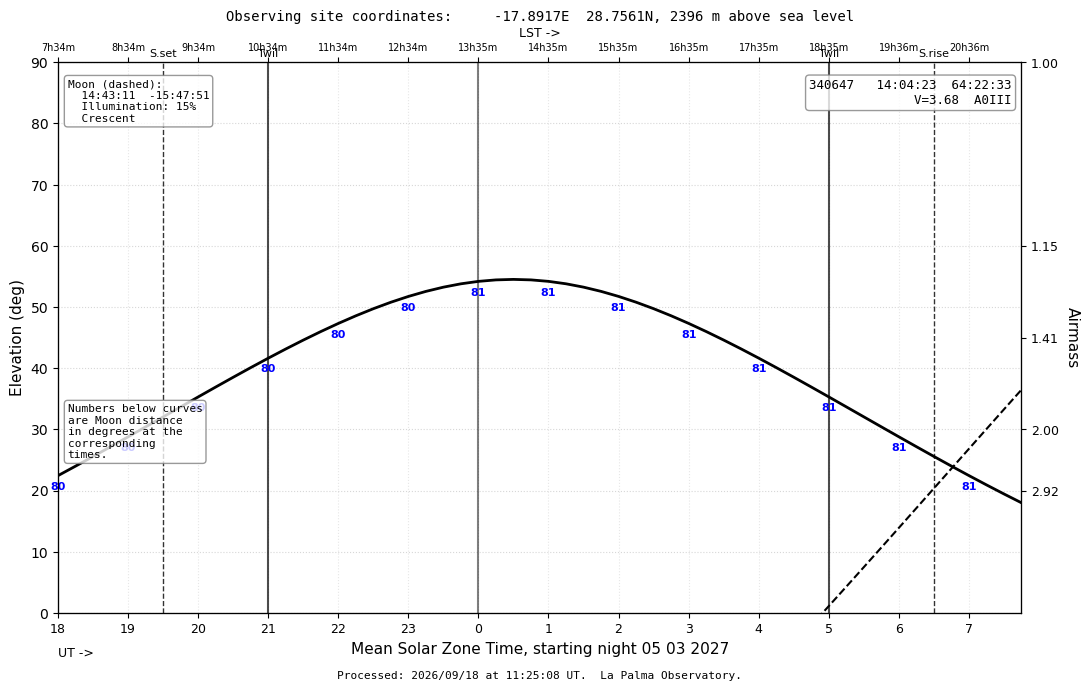

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_340867_2027-05-03.pdf


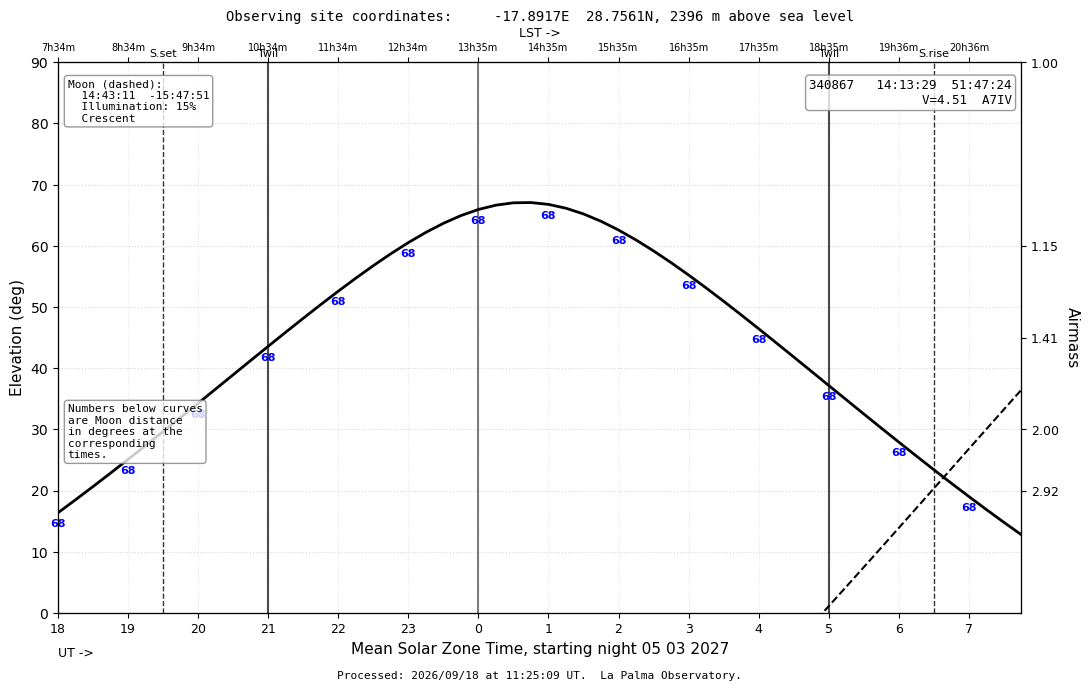

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_340877_2027-05-03.pdf


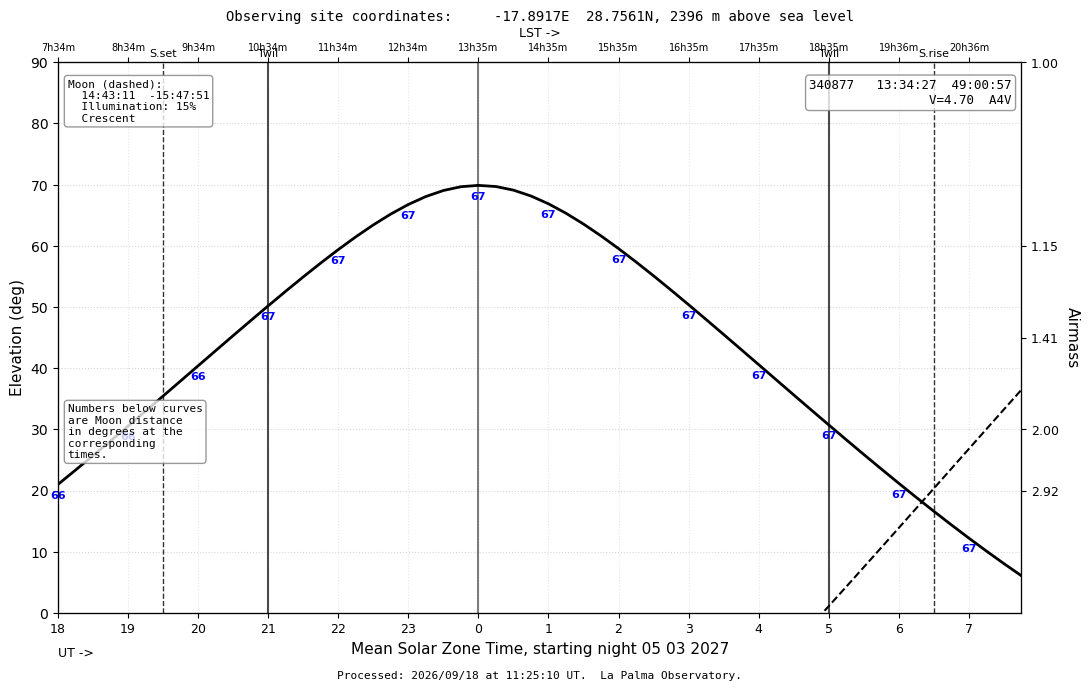

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_349778_2027-05-03.pdf


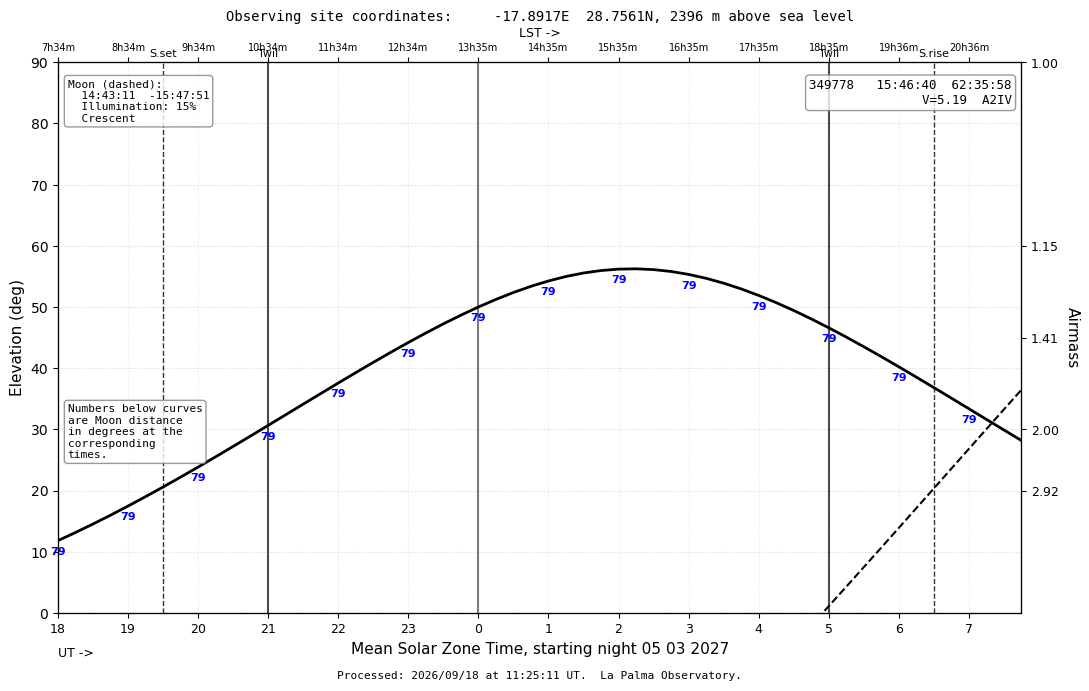

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_370939_2027-05-03.pdf


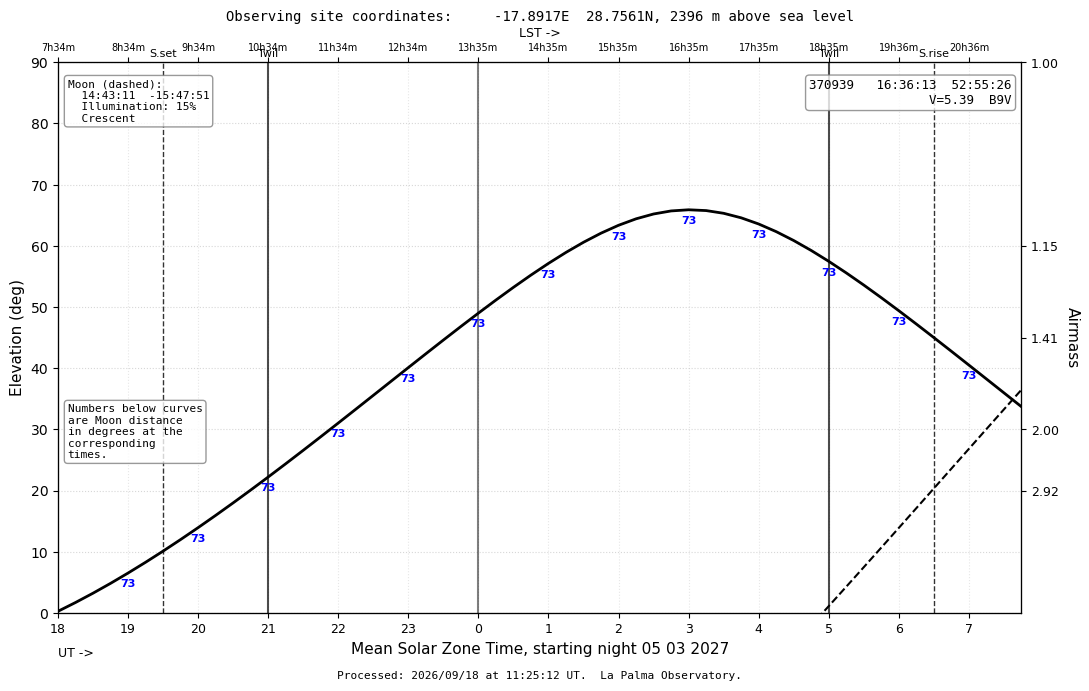

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_390231_2027-05-03.pdf


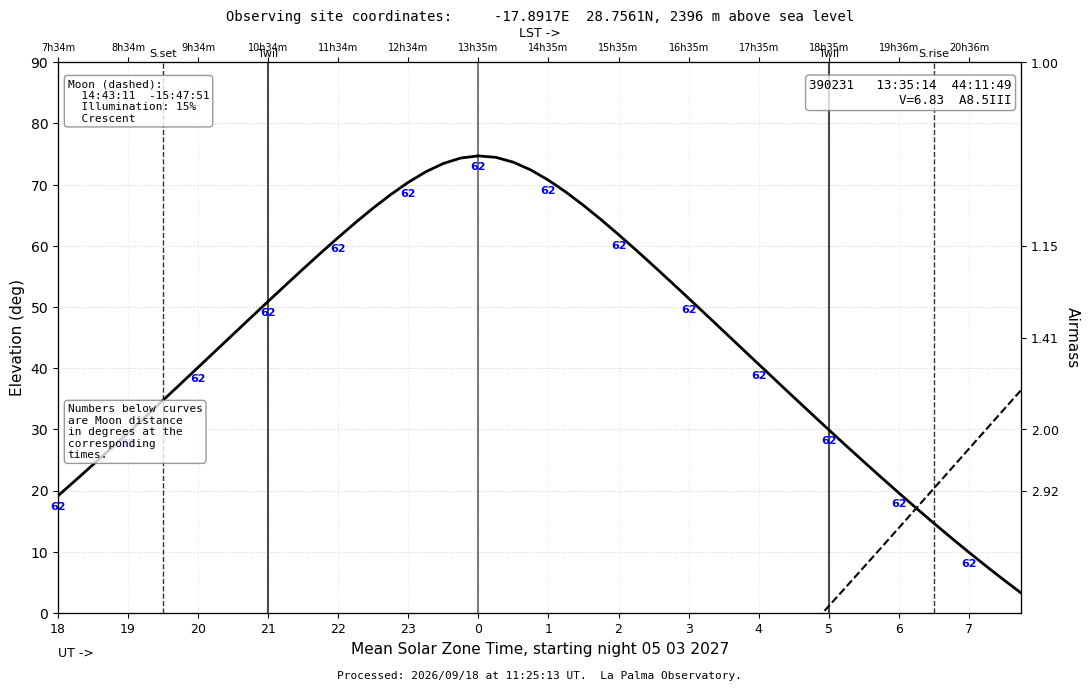

 '2027-05-03 18:30:00.000' '2027-05-03 18:45:00.000'
 '2027-05-03 19:00:00.000' '2027-05-03 19:15:00.000'
 '2027-05-03 19:30:00.000' '2027-05-03 19:45:00.000'
 '2027-05-03 20:00:00.000' '2027-05-03 20:15:00.000'
 '2027-05-03 20:30:00.000' '2027-05-03 20:45:00.000'
 '2027-05-03 21:00:00.000' '2027-05-03 21:15:00.000'
 '2027-05-03 21:30:00.000' '2027-05-03 21:45:00.000'
 '2027-05-03 22:00:00.000' '2027-05-03 22:15:00.000'
 '2027-05-03 22:30:00.000' '2027-05-03 22:45:00.000'
 '2027-05-03 23:00:00.000' '2027-05-03 23:15:00.000'
 '2027-05-03 23:30:00.000' '2027-05-03 23:45:00.000'
 '2027-05-04 00:00:00.000' '2027-05-04 00:15:00.000'
 '2027-05-04 00:30:00.000' '2027-05-04 00:45:00.000'
 '2027-05-04 01:00:00.000' '2027-05-04 01:15:00.000'
 '2027-05-04 01:30:00.000' '2027-05-04 01:45:00.000'
 '2027-05-04 02:00:00.000' '2027-05-04 02:15:00.000'
 '2027-05-04 02:30:00.000' '2027-05-04 02:45:00.000'
 '2027-05-04 03:00:00.000' '2027-05-04 03:15:00.000'
 '2027-05-04 03:30:00.000' '2027-05-04 03:45:0


Trajectory plot saved: plots/trajectory_473126_2027-05-03.pdf


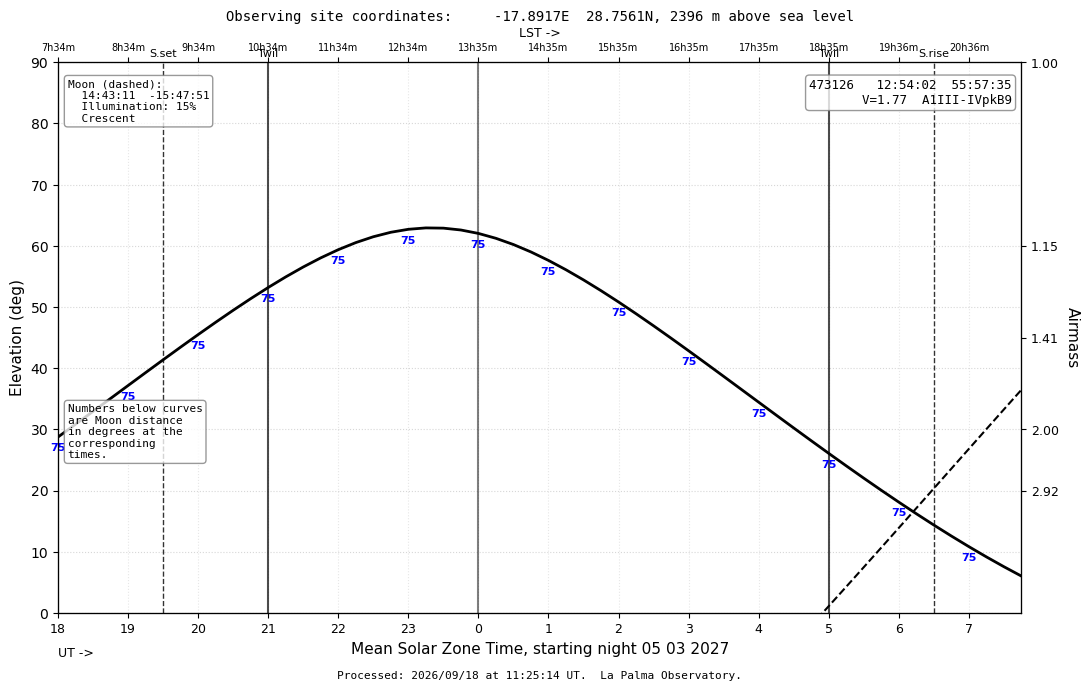

In [13]:
night_index = {d.isoformat(): i for i, (m, d, t) in enumerate(nights)}
# nid = get_best_night_idx(df, nights, 349382)

for star in stars_by_night[date]:
    sid = get_star_idx(df, star)
    nid = night_index[date]
    plot_night_trajectory(df, nights, star_idx=sid, night_idx=nid)


In [14]:
# # --------------------------------------------------------
# # Save
# # --------------------------------------------------------

# observable.to_csv(
#     OUTPUT_FILE,
#     index=False,
# )

# print(
#     f"\nSaved results to:"
#     f"\n{OUTPUT_FILE}"
# )
